In [1]:
import pandas as pd

In [4]:
OPENDS_NAME         = "CAN"
TASK                = "join"
LAKEBENCH_GT_PATH   = f'../data/lakebench/ground truth/opendata_{TASK}_ground_truth.csv' 
OUTPUT_CLEANED_GT   = f'../data/{TASK}/{OPENDS_NAME}_ground_truth.csv'
DATASET_PATH        = f'../data/datasets/datasets_{OPENDS_NAME}.zip'

In [5]:
gt_lakebench = pd.read_csv(LAKEBENCH_GT_PATH)
gt_lakebench.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/lakebench/ground truth/opendata_join_ground_truth.csv'

In [69]:
# if the table name contaqins __ should be removed the row
gt_filtered = gt_lakebench[~gt_lakebench["query_table"].str.contains("__") & ~gt_lakebench["candidate_table"].str.contains("__")]
gt_filtered = gt_filtered[gt_filtered["query_table"] != gt_filtered["candidate_table"]]
gt_filtered.head()

,query_table,candidate_table
0,CAN_CSV0000000000000474.csv,CAN_CSV0000000000004972.csv
1,CAN_CSV0000000000000474.csv,CAN_CSV0000000000013001.csv
2,CAN_CSV0000000000000474.csv,CAN_CSV0000000000002292.csv
3,CAN_CSV0000000000000474.csv,CAN_CSV0000000000027218.csv
4,CAN_CSV0000000000000474.csv,CAN_CSV0000000000005832.csv


In [70]:
len(gt_lakebench), len(gt_filtered)

(49515, 18917)

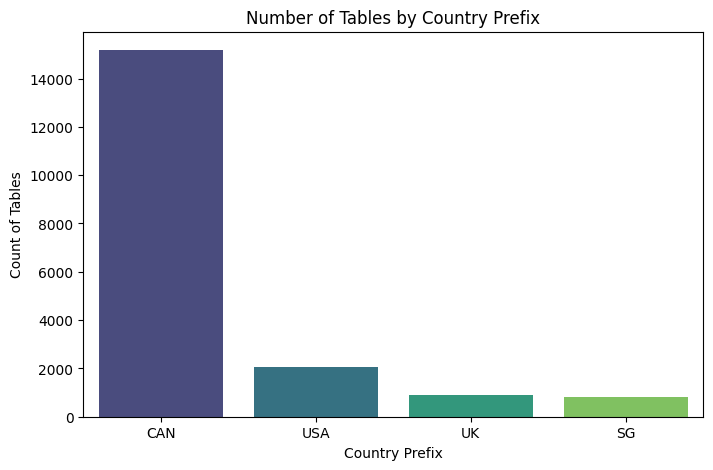

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure DataFrame is a copy to avoid SettingWithCopyWarning
gt_filtered = gt_filtered.copy()

# Extract prefixes
gt_filtered["prefix"] = gt_filtered["query_table"].str.extract(r"^(UK|USA|CAN|SG)")

# Count occurrences of each prefix
prefix_counts = gt_filtered["prefix"].value_counts()

# Plot using seaborn
plt.figure(figsize=(8, 5))
sns.barplot(x=prefix_counts.index, y=prefix_counts.values, hue=prefix_counts.index, palette="viridis", legend=False)

# Labels and title
plt.xlabel("Country Prefix")
plt.ylabel("Count of Tables")
plt.title("Number of Tables by Country Prefix")
plt.xticks(rotation=0)  # Keep labels horizontal
plt.show()


In [72]:
import zipfile

# Open the ZIP file
with zipfile.ZipFile(DATASET_PATH, "r") as z:
    # List files inside the ZIP
    file_list = [
        f
        for f in z.namelist()
        if not f.startswith("__MACOSX")
        and not f.endswith("/")
        and not f.split("/")[-1].startswith("._")
    ]

    # Extract only filenames
    clean_file_names = [f.split("/")[-1] for f in file_list]

print("Filtered Files:", clean_file_names)

Filtered Files: ['CAN_CSV0000000000006102.csv', 'CAN_CSV0000000000000573.csv', 'CAN_CSV0000000000013269.csv', 'CAN_CSV0000000000025903.csv', 'CAN_CSV0000000000002364.csv', 'CAN_CSV0000000000015618.csv', 'CAN_CSV0000000000002402.csv', 'CAN_CSV0000000000011318.csv', 'CAN_CSV0000000000008885.csv', 'CAN_CSV0000000000006670.csv', 'CAN_CSV0000000000009543.csv', 'CAN_CSV0000000000005379.csv', 'CAN_CSV0000000000014274.csv', 'CAN_CSV0000000000016305.csv', 'CAN_CSV0000000000001679.csv', 'CAN_CSV0000000000000567.csv', 'CAN_CSV0000000000007208.csv', 'CAN_CSV0000000000004729.csv', 'CAN_CSV0000000000003046.csv', 'CAN_CSV0000000000005437.csv', 'CAN_CSV0000000000001651.csv', 'CAN_CSV0000000000006880.csv', 'CAN_CSV0000000000001137.csv', 'CAN_CSV0000000000006658.csv', 'CAN_CSV0000000000006894.csv', 'CAN_CSV0000000000001123.csv', 'CAN_CSV0000000000001645.csv', 'CAN_CSV0000000000001876.csv', 'CAN_CSV0000000000027133.csv', 'CAN_CSV0000000000012836.csv', 'CAN_CSV0000000000005392.csv', 'CAN_CSV00000000000212

In [73]:
gt_filtered = gt_filtered[
    (gt_filtered["query_table"].isin(clean_file_names)) & 
    (gt_filtered["candidate_table"].isin(clean_file_names))
]

# Display the filtered DataFrame
print(len(gt_filtered))

15176


In [74]:
gt_filtered_dedup = gt_filtered[['query_table', 'candidate_table']].drop_duplicates()
gt_filtered_dedup

,query_table,candidate_table
0,CAN_CSV0000000000000474.csv,CAN_CSV0000000000004972.csv
1,CAN_CSV0000000000000474.csv,CAN_CSV0000000000013001.csv
2,CAN_CSV0000000000000474.csv,CAN_CSV0000000000002292.csv
3,CAN_CSV0000000000000474.csv,CAN_CSV0000000000027218.csv
4,CAN_CSV0000000000000474.csv,CAN_CSV0000000000005832.csv
...,...,...
31282,CAN_CSV0000000000027430.csv,CAN_CSV0000000000001286.csv
31283,CAN_CSV0000000000027430.csv,CAN_CSV0000000000001296.csv
31286,CAN_CSV0000000000027430.csv,CAN_CSV0000000000027440.csv
31287,CAN_CSV0000000000027430.csv,CAN_CSV0000000000002323.csv


In [75]:
len(gt_filtered_dedup['query_table'].unique()), len(gt_filtered_dedup['candidate_table'].unique())

(616, 2300)

In [76]:
gt_filtered_dedup.reset_index(drop=True).to_csv(OUTPUT_CLEANED_GT, index=False)